<div style="
    width:100%;
    background: linear-gradient(180deg, #000000, #25362a);
    color:#e6ffe6;
    padding:35px 0;
    text-align:center;
    border-radius:12px;
    border: 1px solid #00ff88;
    box-shadow: 0 0 20px rgba(0,255,136,0.15);
">

  <video autoplay loop muted playsinline
         width="600"
         style="
            border-radius:12px;
            border:1px solid #00ff88;
            box-shadow:0 0 25px rgba(0,255,136,0.25);
         ">
    <source src="https://media1.giphy.com/media/G6sJqVpD1U4jC/giphy.mp4" type="video/mp4">
  </video>

  <h3 style="color:#00ff88; margin-top:20px; letter-spacing:0.6px;">
    <b>
      Matrix-Based Solution of 2D Moment-Resisting Frames<br>
      with Axial, Flexural, and Shear Deformations Including Rigid End Offsets
    </b>
  </h3>

  <p><b>Author:</b> Msc. Ing. Carlos Andrés Celi Sánchez</p>
  <p><b>Course:</b> Matrix Structural Analysis</p>
  <p><b>Year:</b> FEB – 2026</p>

</div>


## Stiffness Matrix [Element MF] – Class-Based Implementation in Python

In [1]:
import sys
print(sys.executable)

/home/normando/Dropbox/Root/Github Repositories/kira/bin/python


### **Libraries**

In [2]:
# %matplotlib widget
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from repo_maxtrix_analisys import *

### **1. Purpose of This Section**
---

The purpose of this section is to formally introduce the **local stiffness matrix of a 2D MF element** and to show how this formulation can be implemented in Python using a **class-based approach**.

The explanation is intentionally structured to:
- Emphasize **conceptual understanding**
- Maintain **mathematical rigor**
- Avoid unnecessary programming abstractions
- Facilitate scalability to multiple elements

### **2. Element Matrices of a 2D MF Element**
---

#### **2.1. Local Stiffness Matrix of a 2D MF Element**
---

For a prismatic **2D MF (Moment Frame) element** considering **axial deformation, flexural deformation, shear deformation**, and the presence of **rigid end offsets**, the **local stiffness matrix** is written in a generalized form as:

$$
\mathbf{K}_e =
\begin{bmatrix}
 r      & 0        & 0        & -r     & 0         & 0 \\
 0      & t'       & b''      & 0      & -t'       & b''' \\
 0      & b''      & a''      & 0      & -b''      & a''' \\
 -r     & 0        & 0        & r      & 0         & 0 \\
 0      & -t'      & -b''     & 0      & t'        & -b''' \\
 0      & b'''     & a'''     & 0      & -b'''     & k'''
\end{bmatrix}
$$

This matrix establishes the standard linear relationship:

$$
\mathbf{F}_e = \mathbf{K}_e \, \mathbf{U}_e
$$

Where:
- $\mathbf{F}_e$ is the **local nodal force vector** of the element,
- $\mathbf{U}_e$ is the **local nodal displacement vector**,
- $\mathbf{K}_e$ is the **local stiffness matrix** of the MF element.

The six degrees of freedom associated with the element are:
- Axial displacement at node $A$, $\Delta x_A$
- Transverse displacement at node $A$, $\Delta y_A$
- Rotation at node $A$, $\theta_A$
- Axial displacement at node $B$, $\Delta x_B$
- Transverse displacement at node $B$, $\Delta y_B$
- Rotation at node $B$, $\theta_B$

---

**The coefficients appearing in the stiffness matrix account for axial, flexural, shear, and rigid-end effects and are defined as:**

$$
r = \dfrac{AE}{L}
$$

$$
G = \dfrac{E}{2(1+\nu)}
$$

$$
\beta = \dfrac{6EI}{G A L^2} \, f
$$

Where:
- $f$ is the **shear correction factor**, accounting for the non-uniform shear stress distribution over the cross section.

The remaining stiffness coefficients are expressed as:

$$
t' = \dfrac{12EI}{L^3} \, \dfrac{1}{1 + 2\beta}
$$

$$
b' = \dfrac{6EI}{L^2} \, \dfrac{1}{1 + 2\beta}
$$

$$
k' = \dfrac{2EI}{L} \, \dfrac{2 + \beta}{1 + 2\beta}
$$

$$
a' = \dfrac{2EI}{L} \, \dfrac{1 - \beta}{1 + 2\beta}
$$

---

**When rigid end offsets $d_A$ and $d_B$ are present, the modified stiffness coefficients become:**

$$
b'' = b' + t' \, d_A
$$

$$
b''' = b' + t' \, d_B
$$

$$
a'' = a' + b'(d_A + d_B) + t' d_A d_B
$$

$$
k''' = k' + 2 b' d_B + t' d_B^2
$$

These expressions allow the MF element stiffness matrix to consistently incorporate:
- Shear deformation effects through $\beta$ and $f$,
- Rigid end offsets at both element ends,
- Classical beam–column axial–flexural coupling.

This formulation is particularly suitable for **moment-resisting frame elements** used in refined matrix-based structural analysis.


### **3. Motivation for a Class-Based Representation**
---

In structural analysis, an element is not merely a numerical operation; it is a **physical entity** with:
- Material properties
- Geometric characteristics
- Governing equations

Using a class allows the element to:
- Store its own properties $(E, A, I, L)$
- Compute its stiffness matrix internally
- Be reused consistently in larger structural systems

Conceptually:
- A **function** computes a result.
- A **class** represents an object that *knows how to compute* its result.

This distinction becomes essential when dealing with multiple elements.

### **4. Class Definition: 2D MF Element Stiffness Matrix (Local Coordinates) and Coordinate Transformation Matrix**
---


### **5. Class Definition: MF Element Stiffness Matrix Container (Local Coordinates) and Coordinate Transformation Matrix**
---

Consider a structure composed of $N$ MF elements. Each element contributes a stiffness matrix of size $6 \times 6$.

To store the stiffness matrices of all elements without performing global assembly, a stacked matrix is defined as:

$$
\mathbf{K}_{\text{stacked}} \in \mathbb{R}^{6N \times 6}
$$

Where:
- $\mathbf{K}_{\text{stacked}}$ is the **stacked stiffness matrix**,
- $N$ is the **number of beam elements**,
- Each block of $6$ consecutive rows corresponds to the stiffness matrix of one beam element.

This representation is particularly useful when:
- The objective is to inspect or post-process individual element stiffness matrices,
- The number of elements is variable,
- Global assembly is intentionally deferred to a later stage.

From a matrix-structure perspective, the stacked matrix can be written as:

$$
\mathbf{K}_{\text{stacked}} =
\begin{bmatrix}
\mathbf{K}_e^{(1)} \\
\mathbf{K}_e^{(2)} \\
\vdots \\
\mathbf{K}_e^{(N)}
\end{bmatrix}
$$

Where:
- $\mathbf{K}_e^{(i)}$ is the **local stiffness matrix** of the $i$-th beam element,
- $\mathbf{K}_e^{(i)} \in \mathbb{R}^{6 \times 6}$ for all elements.

As a direct consequence, if three beam elements are considered ($N = 3$), the resulting storage matrix has dimensions:

$$
\mathbf{K}_{\text{stacked}} \in \mathbb{R}^{18 \times 6}
$$

This formulation is independent of material properties, geometry, or boundary conditions, and depends solely on the number of elements and the size of the elemental stiffness matrix.


### **Computation of Local Stiffness and Transformation Matrices for 2D MF Elements**
---

#### Material/section properties, angles, placement vectors, and data

In [3]:
local_dof = 6                                                                                                       # Local DOF per element
Lc = 3.6                                                                                                            # Length of column elements
Lv = 6.0                                                                                                            # Length of beam elements
Ac = 0.50*0.50                                                                                                      # Area for columns
Av = 0.35*0.45                                                                                                      # Area for beams
Ic = 0.50**4 / 12.0                                                                                                 # Inertia for columns
Iv = 0.35*0.45**3 / 12.0                                                                                            # Inertia for beams
E = 2000000                                                                                                         # Young's modulus
L = [Lc, Lc, Lc, Lv, Lv]                                                                                            # Array of element lengths (columns and beams)
A = [Ac, Ac, Ac, Av, Av]                                                                                            # Array of cross-sectional areas (columns and beams)
I = [Ic, Ic, Ic, Iv, Iv]                                                                                            # Array of second moments of area (columns and beams)
nu = 0.20                                                                                                           # Poisson ratio
f  = 6/5                                                                                                            # Shear correction factor
da = 0.00                                                                                                           # Rigid end offset at A (local)
db = 0.00                                                                                                           # Rigid end offset at B (local)
dA = [da, da, da, da, da]                                                                                           # Rigid end offsets at A for each element
dB = [db, db, db, db, db]                                                                                           # Rigid end offsets at B for each element
thetha = [90, -90, -90, 0, 0]                                                                                       # Orientation angles for each element (degrees)

#### Calculation of Local Stiffness Matrices and Coordinate Transformations for MF Elements

In [4]:
# --- Create structure container -----------------------------------------------------------------------------------
structure = MF_L_elements2D()                                                                                       # Create an instance of the MF structure

# --- Add MF elements to the structure -----------------------------------------------------------------------------
for i in np.arange(0, len(L)):                                                                                      # Loop to add each element
    structure.add_element(MF_K_T_L_Element2D(E, A[i], I[i], L[i], nu=nu, f=f, dA=dA[i], dB=dB[i],                   # Add element with specified properties
                                             thetha=thetha[i]))                                                     

#### Basic Visualization of Local Stiffness Matrices for MF Elements

In [5]:
# --- Stack local stiffness matrices --------------------------------------------------------------------------------
K_all = structure.stacked_stiffness_matrices()                                                                      # Stacked stiffness matrix (6N x 6)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
n_elem = len(structure.elements)
n_dof  = local_dof

rows = pd.MultiIndex.from_tuples(
    [(f'Elem_{e+1}', f'DOF_L_{d+1}') for e in range(n_elem) for d in range(n_dof)],
    names=['Element', 'Local DOF']
)

K_all_df = pd.DataFrame(K_all, index=rows, columns=[f'DOF_L_{i}' for i in np.arange(1, K_all.shape[1] + 1)])        # Convert to DataFrame for better visualization
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices

DOF_L_1      DOF_L_2       DOF_L_3        DOF_L_4  \
Element Local DOF                                                            
Elem_1  DOF_L_1    138888.888889     0.000000      0.000000 -138888.888889   
        DOF_L_2         0.000000  2595.083873   4671.150972       0.000000   
        DOF_L_3         0.000000  4671.150972  11301.590267       0.000000   
        DOF_L_4   -138888.888889     0.000000      0.000000  138888.888889   
        DOF_L_5         0.000000 -2595.083873  -4671.150972       0.000000   
        DOF_L_6         0.000000  4671.150972   5514.553230       0.000000   
Elem_2  DOF_L_1    138888.888889     0.000000      0.000000 -138888.888889   
        DOF_L_2         0.000000  2595.083873   4671.150972       0.000000   
        DOF_L_3         0.000000  4671.150972  11301.590267       0.000000   
        DOF_L_4   -138888.888889     0.000000      0.000000  138888.888889   
        DOF_L_5         0.000000 -2595.083873  -4671.150972       0.000000   
        DOF_L_6         0.000000  4671.150972   5514.553230       0.000000   
Elem_3  DOF_L_1    138888.888889     0.000000      0.000000 -138888.888889   
        DOF_L_2         0.000000  2595.083873   4671.150972       0.000000   
        DOF_L_3         0.000000  4671.150972  11301.590267       0.000000   
        DOF_L_4   -138888.888889     0.000000      0.000000  138888.888889   
        DOF_L_5         0.000000 -2595.083873  -4671.150972       0.000000   
        DOF_L_6         0.000000  4671.150972   5514.553230       0.000000   
Elem_4  DOF_L_1     52500.000000     0.000000      0.000000  -52500.000000   
        DOF_L_2         0.000000   292.547922    877.643766       0.000000   
        DOF_L_3         0.000000   877.643766   3518.868799       0.000000   
        DOF_L_4    -52500.000000     0.000000      0.000000   52500.000000   
        DOF_L_5         0.000000  -292.547922   -877.643766       0.000000   
        DOF_L_6         0.000000   877.643766   1746.993799       0.000000   
Elem_5  DOF_L_1     52500.000000     0.000000      0.000000  -52500.000000   
        DOF_L_2         0.000000   292.547922    877.643766       0.000000   
        DOF_L_3         0.000000   877.643766   3518.868799       0.000000   
        DOF_L_4    -52500.000000     0.000000      0.000000   52500.000000   
        DOF_L_5         0.000000  -292.547922   -877.643766       0.000000   
        DOF_L_6         0.000000   877.643766   1746.993799       0.000000   

                       DOF_L_5       DOF_L_6  
Element Local DOF                             
Elem_1  DOF_L_1       0.000000      0.000000  
        DOF_L_2   -2595.083873   4671.150972  
        DOF_L_3   -4671.150972   5514.553230  
        DOF_L_4       0.000000      0.000000  
        DOF_L_5    2595.083873  -4671.150972  
        DOF_L_6   -4671.150972  11301.590267  
Elem_2  DOF_L_1       0.000000      0.000000  
        DOF_L_2   -2595.083873   4671.150972  
        DOF_L_3   -4671.150972   5514.553230  
        DOF_L_4       0.000000      0.000000  
        DOF_L_5    2595.083873  -4671.150972  
        DOF_L_6   -4671.150972  11301.590267  
Elem_3  DOF_L_1       0.000000      0.000000  
        DOF_L_2   -2595.083873   4671.150972  
        DOF_L_3   -4671.150972   5514.553230  
        DOF_L_4       0.000000      0.000000  
        DOF_L_5    2595.083873  -4671.150972  
        DOF_L_6   -4671.150972  11301.590267  
Elem_4  DOF_L_1       0.000000      0.000000  
        DOF_L_2    -292.547922    877.643766  
        DOF_L_3    -877.643766   1746.993799  
        DOF_L_4       0.000000      0.000000  
        DOF_L_5     292.547922   -877.643766  
        DOF_L_6    -877.643766   3518.868799  
Elem_5  DOF_L_1       0.000000      0.000000  
        DOF_L_2    -292.547922    877.643766  
        DOF_L_3    -877.643766   1746.993799  
        DOF_L_4       0.000000      0.000000  
        DOF_L_5     292.547922   -877.643766  
        DOF_L_6    -877.643766   3518.868799

#### Optionally, a styling function is created for the DataFrame containing the local-coordinate stiffness matrices of each element

In [6]:
K_all_df.head(len(K_all_df))                                                                                        # Display stacked matrices
def style_by_element(df):                                                                                           # Define styling function                                        
    elems = df.index.get_level_values(0)                                                                            # Get 'Element' level from MultiIndex   
    colors = ["#9b8bf8","#ffb4b4"]                                                                                  # Define a simple color palette

    styles = pd.DataFrame('', index=df.index, columns=df.columns)                                                   # Initialize styles DataFrame

    for i, e in enumerate(elems.unique()):                                                                          # loop through unique elements                                                                                                                                                                               
        c = colors[i % len(colors)]                                                                                 # Select color from palette
        mask = (elems == e)                                                                                         # Create mask for current element   
        styles.loc[mask, :] = f'background-color: {c}25'                                                            # Apply background color with transparency                                                                               

    return styles                                                                                                   # Return the styles DataFrame

K_all_df_styled = K_all_df.style.apply(style_by_element, axis=None)\
                                .format("{:,.3f}")                                                                  # Apply styling and formatting

K_all_df_styled                                                                                                     # Display styled DataFrame

#### Example: Extraction of the Stiffness Matrix (local cordinates) of an Individual Element


In [7]:
if len(structure.elements) > 0:                                                                                     # Check if elements were added to the structure 
    n_elem = len(structure.elements)                                                                                # Get the number of elements in the structure
    print(f"\x1b[1;32m✅ The element stiffness matrices in local coordinates have been generated.\x1b[0m")          # Print success message with green color
    print(f"🧩 Number of MF elements in the structure: \x1b[1;34m{n_elem}\x1b[0m")                                  # Print number of elements with blue color
else:
    print(f"\x1b[1;31m🚫 Failed to generate element stiffness matrices in local coordinates.\x1b[0m")               # Print error message with red color              

✅ The element stiffness matrices in local coordinates have been generated.
🧩 Number of MF elements in the structure: 5


In [8]:
num_elem = 3                                                                                                        # Number of elements to display

if num_elem > len(structure.elements):                                                                              # Check if requested number of elements exceeds available
    print(f"\x1b[1;33m⚠️ Requested number of elements exceeds available.\x1b[0m")                                   # Display warning and show all available elements
else:
    elemL = structure.elements[num_elem-1].stiffness_matrix_MF_L()                                                  # Stiffness matrix of the second element      
    rows = pd.MultiIndex.from_tuples(
        [(f'Elem_{num_elem}', f'DOF_L_{d+1}') for e in range(1) for d in range(n_dof)],
        names=['Element', 'Local DOF']
    )      
    rows       
                                                                                
    elemL_df = pd.DataFrame(elemL, index=rows, columns=[f'DOF_{i}' for i in np.arange(1, elemL.shape[1] + 1)])      # Convert to DataFrame for better visualization
elemL_df.head(len(elemL_df))                                                                                        # Display the stiffness matrix of the second element                

DOF_1        DOF_2         DOF_3          DOF_4  \
Element Local DOF                                                            
Elem_3  DOF_L_1    138888.888889     0.000000      0.000000 -138888.888889   
        DOF_L_2         0.000000  2595.083873   4671.150972       0.000000   
        DOF_L_3         0.000000  4671.150972  11301.590267       0.000000   
        DOF_L_4   -138888.888889     0.000000      0.000000  138888.888889   
        DOF_L_5         0.000000 -2595.083873  -4671.150972       0.000000   
        DOF_L_6         0.000000  4671.150972   5514.553230       0.000000   

                         DOF_5         DOF_6  
Element Local DOF                             
Elem_3  DOF_L_1       0.000000      0.000000  
        DOF_L_2   -2595.083873   4671.150972  
        DOF_L_3   -4671.150972   5514.553230  
        DOF_L_4       0.000000      0.000000  
        DOF_L_5    2595.083873  -4671.150972  
        DOF_L_6   -4671.150972  11301.590267

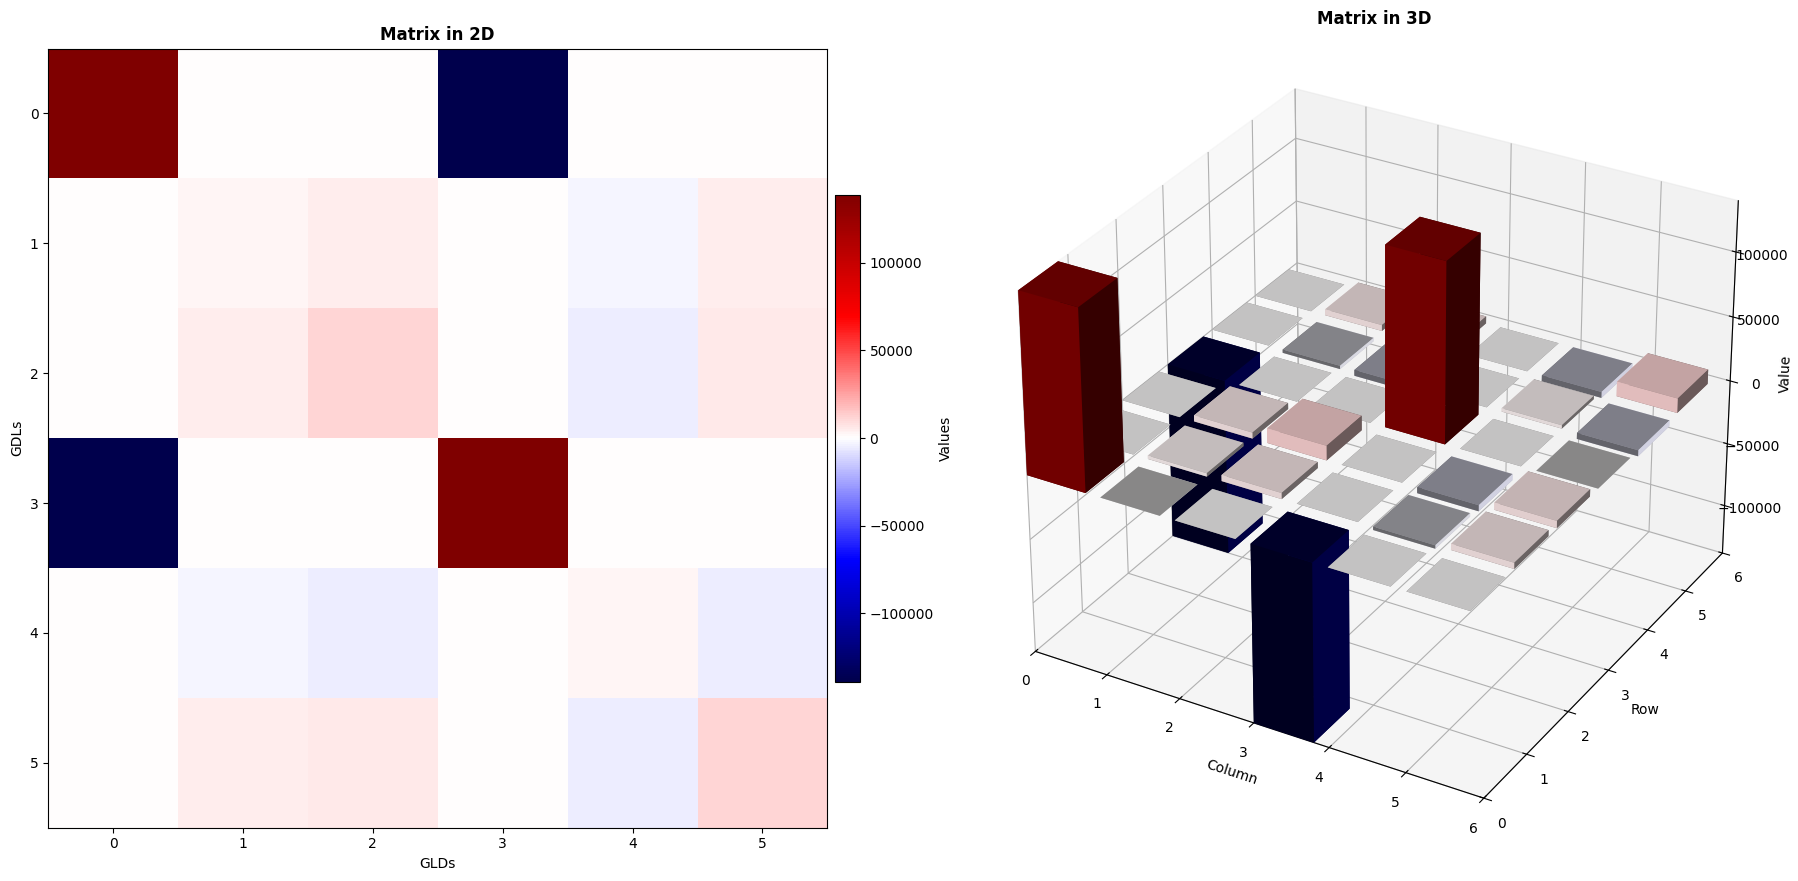

In [14]:
visualM = M_visual_2D_3D(elemL)
visualM.M_visual()

#### Basic Visualization of Transformation Matrices for MF Elements

In [10]:
# --- Stack Transformation matrices --------------------------------------------------------------------------------
T_all = structure.stacked_transformation_matrices()                                                                 # Stacked transformation matrix (6N x 6)

# --- Convert to DataFrame for visualization -----------------------------------------------------------------------
rows = pd.MultiIndex.from_tuples(
    [(f'Elem_{e+1}', f'DOF_L_G_{d+1}') for e in range(n_elem) for d in range(n_dof)],
    names=['Element', 'Local - Global DOF']
)

T_all_df = pd.DataFrame(T_all, index=rows, columns=[f'DOF_L_G_{i}' for i in np.arange(1, T_all.shape[1] + 1)])      # Convert to DataFrame for better visualization
T_all_df.head(len(T_all_df))                                                                                        # Display stacked matrices

DOF_L_G_1     DOF_L_G_2  DOF_L_G_3  \
Element Local - Global DOF                                          
Elem_1  DOF_L_G_1           6.123234e-17 -1.000000e+00        0.0   
        DOF_L_G_2           1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_2  DOF_L_G_1           6.123234e-17  1.000000e+00        0.0   
        DOF_L_G_2          -1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_3  DOF_L_G_1           6.123234e-17  1.000000e+00        0.0   
        DOF_L_G_2          -1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_4  DOF_L_G_1           1.000000e+00 -0.000000e+00        0.0   
        DOF_L_G_2           0.000000e+00  1.000000e+00        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   
Elem_5  DOF_L_G_1           1.000000e+00 -0.000000e+00        0.0   
        DOF_L_G_2           0.000000e+00  1.000000e+00        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   

                               DOF_L_G_4     DOF_L_G_5  DOF_L_G_6  
Element Local - Global DOF                                         
Elem_1  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17 -1.000000e+00        0.0  
        DOF_L_G_5           1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_2  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17  1.000000e+00        0.0  
        DOF_L_G_5          -1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_3  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17  1.000000e+00        0.0  
        DOF_L_G_5          -1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_4  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           1.000000e+00 -0.000000e+00        0.0  
        DOF_L_G_5           0.000000e+00  1.000000e+00        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0  
Elem_5  DOF_L_G_1           0.000000e+00  0.000000e+00

#### Example: Extraction of the Transformation Matrix of an Individual Element

In [11]:
if len(structure.elements) > 0:                                                                                     # Check if elements were added to the structure 
    n_elem = len(structure.elements)                                                                                # Get the number of elements in the structure
    print(f"\x1b[1;32m✅ The element transformation matrices have been generated.\x1b[0m")                         # Print success message with green color
    print(f"🧩 Number of MF elements in the structure: \x1b[1;34m{n_elem}\x1b[0m")                                  # Print number of elements with blue color
else:
    print(f"\x1b[1;31m🚫 Failed to generate element transformation matrices.\x1b[0m")                               # Print error message with red color  

✅ The element transformation matrices have been generated.
🧩 Number of MF elements in the structure: 5


In [12]:
num_elem = 1                                                                                                        # Number of elements to display
if num_elem > len(structure.elements):                                                                              # Check if requested number of elements exceeds available
    print(f"\x1b[1;33m⚠️ Requested number of elements exceeds available.\x1b[0m")                                   # Display warning and show all available elements
else:
    elemT = structure.elements[num_elem-1].transformation_matrix_2D()                                               # Transformation matrix of the "n" element      
    rows = pd.MultiIndex.from_tuples(
        [(f'Elem_{num_elem}', f'DOF_L_G_{d+1}') for e in range(1) for d in range(n_dof)],
        names=['Element', 'Local - Global DOF']
    )      
    rows       
                                                                                
    elemT_df = pd.DataFrame(elemT, index=rows, columns=[f'DOF_L_G_{i}' for i in np.arange(1, elemT.shape[1] + 1)])  # Convert to DataFrame for better visualization
elemT_df.head(len(elemT_df))                                                                                        # Display the transformation matrix of the "n" element 

DOF_L_G_1     DOF_L_G_2  DOF_L_G_3  \
Element Local - Global DOF                                          
Elem_1  DOF_L_G_1           6.123234e-17 -1.000000e+00        0.0   
        DOF_L_G_2           1.000000e+00  6.123234e-17        0.0   
        DOF_L_G_3           0.000000e+00  0.000000e+00        1.0   
        DOF_L_G_4           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_5           0.000000e+00  0.000000e+00        0.0   
        DOF_L_G_6           0.000000e+00  0.000000e+00        0.0   

                               DOF_L_G_4     DOF_L_G_5  DOF_L_G_6  
Element Local - Global DOF                                         
Elem_1  DOF_L_G_1           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_2           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_3           0.000000e+00  0.000000e+00        0.0  
        DOF_L_G_4           6.123234e-17 -1.000000e+00        0.0  
        DOF_L_G_5           1.000000e+00  6.123234e-17        0.0  
        DOF_L_G_6           0.000000e+00  0.000000e+00        1.0